In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import fetch_california_housing

In [2]:
df = pd.read_csv('student_exam_scores.csv')

In [3]:
df.shape

(400, 3)

In [4]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [12]:
base_estimator = DecisionTreeClassifier(max_depth=1)
classifier = AdaBoostClassifier(base_estimator,n_estimators=50)

In [13]:
classifier.fit(x_train,y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [14]:
y_pred = classifier.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score,classification_report,precision_score,log_loss

In [16]:
print(accuracy_score(y_test,y_pred))

1.0


In [17]:
precision_score(y_test,y_pred)

1.0

In [19]:
log_loss(y_test, classifier.predict_proba(x_test))

0.33135093790571574

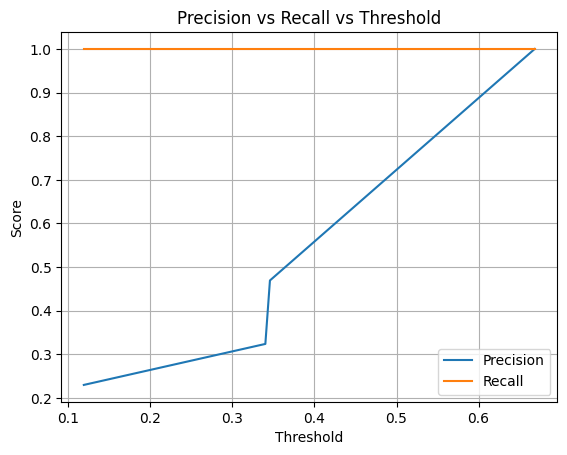

In [21]:
from sklearn.metrics import precision_recall_curve

probs = classifier.predict_proba(x_test)[:, 1]  # probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision vs Recall vs Threshold')
plt.grid()
plt.show()


In [26]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))


[[77  0]
 [ 0 23]]


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(classifier, x, y, cv=5, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation accuracy scores: [1.     1.     1.     0.9875 1.    ]
Mean accuracy: 0.9974999999999999
